# Lab 07
===
- Sử dụng ảnh cameraman (ảnh I), thêm vào ảnh 50% nhiễu salt and pepper (ảnh J).
1. Sử dụng LoG để tách biên => Biên E1

2. Sử dụng Canny operator để tách biên => E2

3. Sử dụng thuật toán median filter ( đã cài đặt viết ở lab 4) để lọc nhiễu cho ảnh J, sử dung kannel window 8x8

4. Kết hợp ảnh J+E1, J+E2 để tạo ra hai phiên bản ảnh khử nhiễu mới.

In [77]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def show_images(panels, figsize=None):
    if figsize is None:
        figsize = (5 * len(panels), 5)

    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    if len(panels) == 1:
        axes = [axes]

    for ax, (title, image) in zip(axes, panels):
        ax.set_title(title)
        if image.ndim == 2:
            ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(image)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def load_grayscale_image(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Khong tim thay anh tai: {image_path}")
    return image


def add_salt_and_pepper_noise(image, amount=0.5, salt_ratio=0.5, seed=42):
    if not 0 <= amount <= 1:
        raise ValueError("amount phai nam trong [0, 1]")
    if not 0 <= salt_ratio <= 1:
        raise ValueError("salt_ratio phai nam trong [0, 1]")

    rng = np.random.default_rng(seed)
    noisy = image.copy()
    random_map = rng.random(image.shape)
    salt_threshold = amount * salt_ratio

    noisy[random_map < salt_threshold] = 255
    noisy[(random_map >= salt_threshold) & (random_map < amount)] = 0
    return noisy


def log_edge_detection(
    image,
    blur_ksize=(5, 5),
    laplace_ksize=3,
    sigma=0,
    median_ksize=0,
    threshold=10,
):
    if median_ksize and median_ksize > 1:
        if median_ksize % 2 == 0:
            median_ksize += 1
        image = cv2.medianBlur(image, int(median_ksize))

    blurred = cv2.GaussianBlur(image, blur_ksize, sigma)
    laplacian = cv2.Laplacian(blurred, cv2.CV_64F, ksize=laplace_ksize)

    # Zero-crossing → đường mảnh tự nhiên
    pos = laplacian > 0
    neg = laplacian < 0
    edges = np.zeros(laplacian.shape, dtype=np.uint8)
    for shift in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
        sp = np.roll(pos, shift, axis=(0, 1))
        sn = np.roll(neg, shift, axis=(0, 1))
        edges[(pos & sn) | (neg & sp)] = 255

    # Lọc zero-crossing yếu bằng biên độ raw (chưa normalize)
    magnitude = np.abs(laplacian)
    edges[magnitude < threshold] = 0

    response = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return blurred, response, edges


def canny_edge_detection(image, blur_ksize=(5, 5), sigma=0):
    blurred = cv2.GaussianBlur(image, blur_ksize, sigma)
    median_value = float(np.median(blurred))
    lower = int(max(0, 0.66 * median_value))
    upper = int(min(255, 1.33 * median_value))
    edges = cv2.Canny(blurred, lower, upper)
    return blurred, edges, lower, upper


def median_filter_manual(image, kernel_size=8):
    if kernel_size < 1:
        raise ValueError("kernel_size phai >= 1")

    pad = kernel_size // 2
    padded = np.pad(image, pad_width=pad, mode="reflect")
    filtered = np.empty_like(image)

    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            window = padded[row:row + kernel_size, col:col + kernel_size]
            filtered[row, col] = np.median(window)

    return filtered


def edge_guided_composite(noisy_image, denoised_image, edge_map):
    composite = denoised_image.copy()
    composite[edge_map > 0] = noisy_image[edge_map > 0]
    return composite


Image path: cman.tif
Shape: (256, 256), dtype: uint8, range: [22, 255]


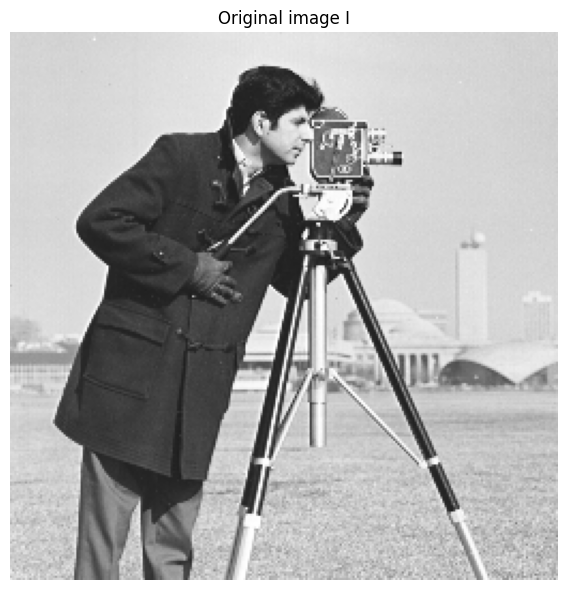

In [78]:
image_path = Path("cman.tif")
I = load_grayscale_image(image_path)

print(f"Image path: {image_path}")
print(f"Shape: {I.shape}, dtype: {I.dtype}, range: [{I.min()}, {I.max()}]")

show_images([
    ("Original image I", I),
], figsize=(6, 6))


Da tao anh J voi 50% nhieu salt-and-pepper
J range: [0, 255], dtype: uint8


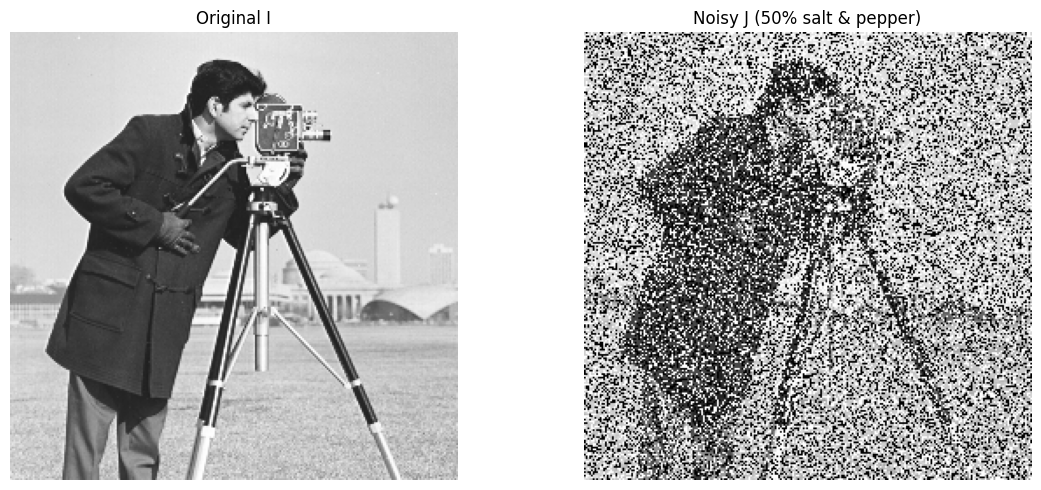

In [79]:
J = add_salt_and_pepper_noise(I, amount=0.5, salt_ratio=0.5, seed=42)

print("Da tao anh J voi 50% nhieu salt-and-pepper")
print(f"J range: [{J.min()}, {J.max()}], dtype: {J.dtype}")

show_images([
    ("Original I", I),
    ("Noisy J (50% salt & pepper)", J),
], figsize=(12, 5))


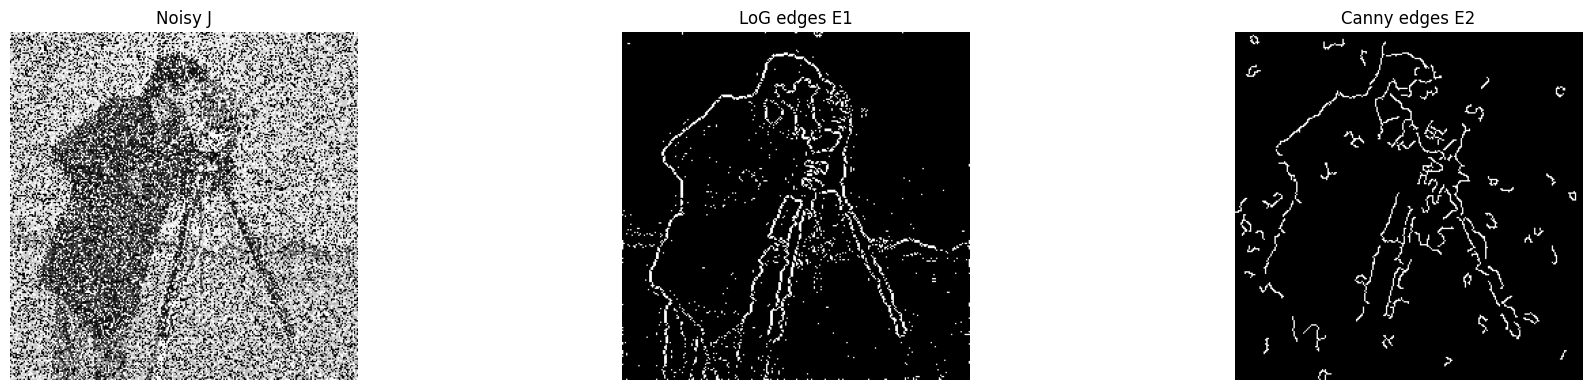

In [88]:
# LoG: loc median trong ham + Gaussian de giam salt & pepper, zero-crossing + nguong nhe hon
blurred_log, E1_response, E1 = log_edge_detection(
    J,
    blur_ksize=(11, 11),
    sigma=1.5,
    median_ksize=9,
    threshold=8,  
)

# Canny giu nguyen de so sanh
blurred_canny, E2, lower, upper = canny_edge_detection(
    J, blur_ksize=(15, 15), sigma=1.8
)

show_images([
    ("Noisy J", J),
    ("LoG edges E1", E1),
    ("Canny edges E2", E2),
], figsize=(20, 4))


Da loc median thu cong voi kernel 8x8
J_median range: [32, 255], dtype: uint8


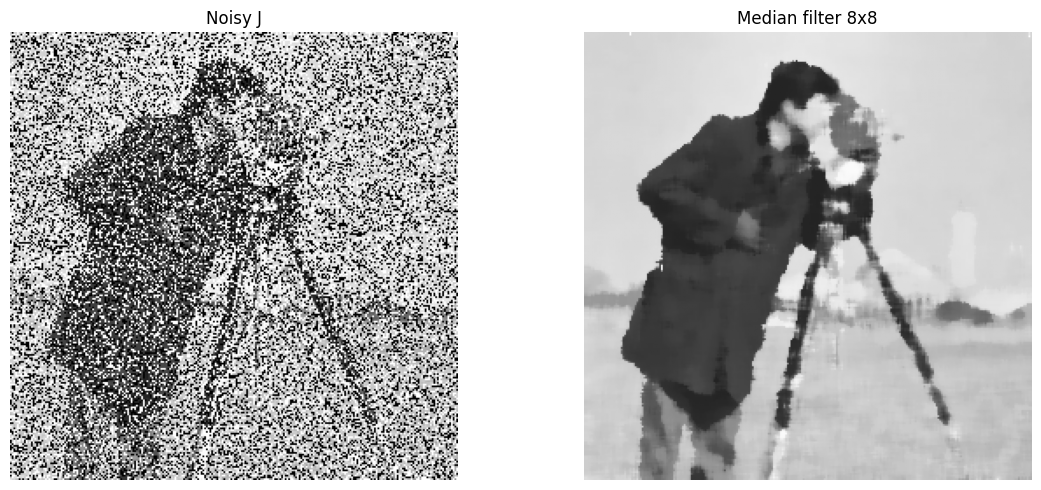

In [81]:
J_median = median_filter_manual(J, kernel_size=8)

print("Da loc median thu cong voi kernel 8x8")
print(f"J_median range: [{J_median.min()}, {J_median.max()}], dtype: {J_median.dtype}")

show_images([
    ("Noisy J", J),
    ("Median filter 8x8", J_median),
], figsize=(12, 5))


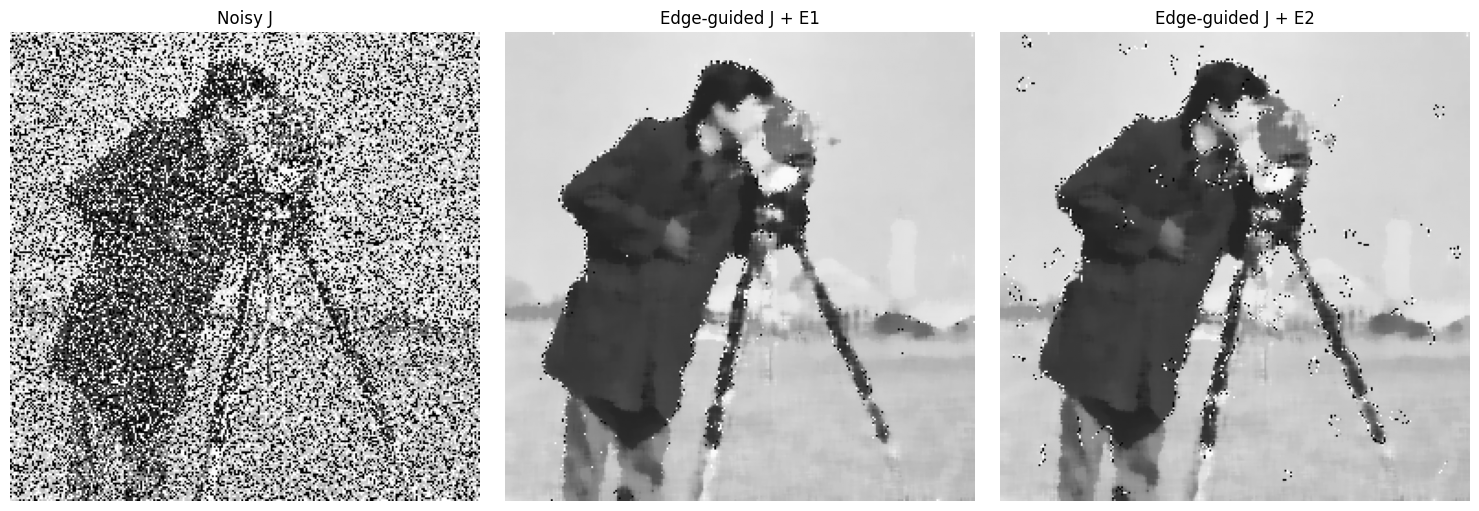

In [82]:
J_E1 = edge_guided_composite(J, J_median, E1)
J_E2 = edge_guided_composite(J, J_median, E2)

show_images([
    ("Noisy J", J),
    ("Edge-guided J + E1", J_E1),
    ("Edge-guided J + E2", J_E2),
], figsize=(15, 5))
